# 05 - EfficientNetB0 Transfer Learning

This experiment uses EfficientNetB0 pretrained on ImageNet. It follows the best-performing data strategy so far:

- on-the-fly augmentation during training
- mild targeted oversampling on the training dataframe
- no class weights

This notebook is intended to run in WSL2/GPU. It still works on CPU, but training will be slower.

Current best candidate before this notebook:

- `mobilenetv2_aug_oversampled_finetuned_wsl`
- accuracy about 0.9604
- macro F1 about 0.9368


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system


## 2. Imports and configuration

EfficientNetB0 pretrained weights may be downloaded on the first run. If internet is unavailable, setting `PRETRAINED_WEIGHTS = None` will test the pipeline but is no longer a transfer-learning experiment.


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)

# Use grouped source-image splits to avoid offline-augmentation leakage.
SPLITS_DIR = GROUPED_SPLITS_DIR
from src.data.augmentations import build_training_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.efficientnetb0_model import build_efficientnetb0_model
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "efficientnetb0_aug_oversampled"
TARGET_MIN_COUNT = 500
PRETRAINED_WEIGHTS = "imagenet"

HEAD_EPOCHS = 8
HEAD_LEARNING_RATE = 1e-3


EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Input size:", IMAGE_SIZE)
print("Target minimum train count:", TARGET_MIN_COUNT)


I0000 00:00:1777438148.029930   19906 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777438148.083788   19906 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777438176.751754   19906 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: efficientnetb0_aug_oversampled
Input size: (224, 224)
Target minimum train count: 500


## 3. Load split files and class names

If the split CSV files contain Windows paths such as `D:\...`, the dataloader converts them to `/mnt/d/...` automatically when running under WSL.


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 19674 4788 4815
Classes: 28


## 4. Mild targeted oversampling

Only the training rows are oversampled. Validation and test remain untouched.


In [4]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = (
    oversampling_summary["oversampled_train_count"]
    - oversampling_summary["original_train_count"]
)
oversampling_summary["oversampled_ratio"] = (
    oversampling_summary["oversampled_train_count"]
    / oversampling_summary["original_train_count"]
).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))
print("Added rows:", len(train_oversampled_df) - len(train_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
21,Pomegranate__Rotten,131,500,369,3.82
14,Jujube__Healthy,132,500,368,3.79
11,Grape__Rotten,134,500,366,3.73
15,Jujube__Rotten,134,500,366,3.73
12,Guava__Healthy,134,500,366,3.73
10,Grape__Healthy,135,500,365,3.70
13,Guava__Rotten,135,500,365,3.70
20,Pomegranate__Healthy,137,500,363,3.65
7,Carrot__Rotten,390,500,110,1.28
5,Bellpepper__Rotten,390,500,110,1.28


Original train rows: 19674
Oversampled train rows: 23590
Added rows: 3916


## 5. Build TensorFlow datasets


In [5]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


I0000 00:00:1777438201.097947   19906 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Build EfficientNetB0 model

The dataloader returns `0..1` images. The EfficientNetB0 builder rescales to `0..255` internally before passing images into the Keras application model.


In [6]:
augmentation = build_training_augmentation()
model = build_efficientnetb0_model(
    num_classes=NUM_CLASSES,
    augmentation=augmentation,
    dropout_rate=0.3,
    train_base=False,
    weights=PRETRAINED_WEIGHTS,
)
model = compile_model(model, learning_rate=HEAD_LEARNING_RATE)
model.summary()


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0_rescale_to_255   │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 28)             │        35,868 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,085,439 (15.58 MB)

 Trainable params: 35,868 (140.11 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7. Train classifier head with frozen EfficientNetB0 base


In [7]:
head_checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_head_best.keras"

head_history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=HEAD_EPOCHS,
    checkpoint_path=head_checkpoint_path,
)


Epoch 1/8


I0000 00:00:1777438222.321361   20418 cuda_dnn.cc:461] Loaded cuDNN version 92100


386/738 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.6234 - loss: 1.4772

W0000 00:00:1777438263.530083   20548 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


675/738 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7077 - loss: 1.1568

...

738/738 ━━━━━━━━━━━━━━━━━━━━ 87s 115ms/step - accuracy: 0.9680 - loss: 0.1040 - val_accuracy: 0.9628 - val_loss: 0.1302 - learning_rate: 0.0010
Epoch 8/8
386/738 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.9704 - loss: 0.0930

W0000 00:00:1777438870.931084   23299 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


675/738 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.9693 - loss: 0.0962

W0000 00:00:1777438900.614073   23294 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


738/738 ━━━━━━━━━━━━━━━━━━━━ 89s 118ms/step - accuracy: 0.9681 - loss: 0.0996 - val_accuracy: 0.9649 - val_loss: 0.1255 - learning_rate: 0.0010


## 8. Fine-tuning note

Fine-tuning is handled separately in `05B_efficientnetb0_finetune_wsl.ipynb`.


## 9. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate,stage
3,0.958584,0.141991,0.956349,0.153644,0.001,head
4,0.963968,0.124126,0.959900,0.141459,0.001,head
5,0.964731,0.115288,0.963241,0.133611,0.001,head
6,0.967953,0.104001,0.962824,0.130163,0.001,head
7,0.968122,0.099561,0.964912,0.125486,0.001,head


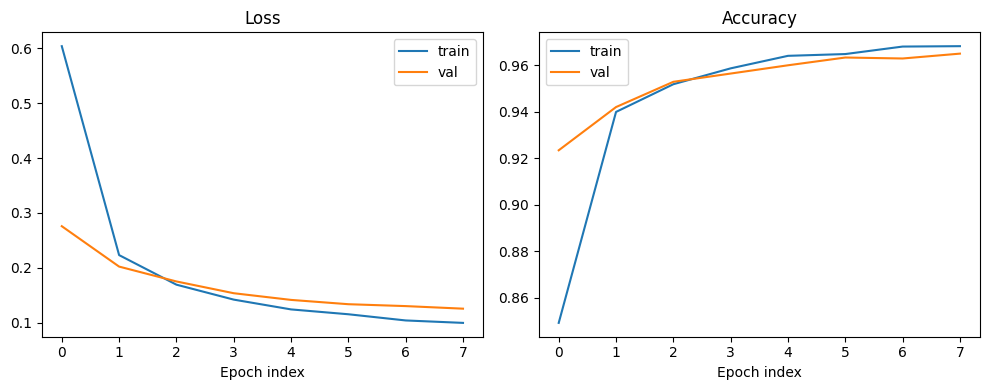

In [8]:
head_history_df = pd.DataFrame(head_history.history)
head_history_df["stage"] = "head"
history_df = head_history_df.copy()
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df.index, history_df["loss"], label="train")
plt.plot(history_df.index, history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch index")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df.index, history_df["accuracy"], label="train")
plt.plot(history_df.index, history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch index")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 10. Evaluate on test set


In [9]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


W0000 00:00:1777438936.354448   23682 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


,precision,recall,f1-score,support
Apple__Healthy,0.967822,0.992386,0.979950,394.000000
Apple__Rotten,0.964876,0.962887,0.963880,485.000000
Banana__Healthy,0.982877,1.000000,0.991364,287.000000
Banana__Rotten,0.995842,0.991718,0.993776,483.000000
Bellpepper__Healthy,0.961538,0.980392,0.970874,102.000000
Bellpepper__Rotten,0.931818,0.820000,0.872340,100.000000
Carrot__Healthy,0.935780,0.990291,0.962264,103.000000
Carrot__Rotten,0.987805,0.852632,0.915254,95.000000
Cucumber__Healthy,0.893805,0.990196,0.939535,102.000000
Cucumber__Rotten,0.965517,0.875000,0.918033,96.000000


Test accuracy: 0.9666
Macro F1: 0.9532
Weighted F1: 0.9664


## 11. Focus on weak classes


In [10]:
weak_classes = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
    "Guava__Rotten",
    "Jujube__Rotten",
]

available_weak_classes = [name for name in weak_classes if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.957447,0.937500,0.947368,96.0
Bellpepper__Rotten,0.931818,0.820000,0.872340,100.0
Potato__Rotten,0.876404,0.804124,0.838710,97.0
Pomegranate__Rotten,0.772727,0.971429,0.860759,35.0
Carrot__Rotten,0.987805,0.852632,0.915254,95.0
Guava__Rotten,0.744186,1.000000,0.853333,32.0
Jujube__Rotten,0.967742,0.967742,0.967742,31.0


## 12. Compare with saved reports


In [22]:
comparison_paths = {
    "plain_baseline": FIGURES_DIR / "baseline_cnn_classification_report.csv",
    "baseline_aug_oversampled": FIGURES_DIR / "baseline_cnn_aug_oversampled_classification_report.csv",
    "mobilenetv2_frozen": FIGURES_DIR / "mobilenetv2_aug_oversampled_classification_report.csv",
    "mobilenetv2_finetuned_wsl": FIGURES_DIR / "mobilenetv2_aug_oversampled_finetuned_wsl_classification_report.csv",
}

rows = []
for name, path in comparison_paths.items():
    if path.exists():
        prev = pd.read_csv(path, index_col=0)
        rows.append({
            "experiment": name,
            "accuracy": float(prev.loc["accuracy", "precision"]),
            "macro_f1": float(prev.loc["macro avg", "f1-score"]),
            "weighted_f1": float(prev.loc["weighted avg", "f1-score"]),
        })

rows.append({
    "experiment": EXPERIMENT_NAME,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,experiment,accuracy,macro_f1,weighted_f1
0,plain_baseline,0.730218,0.673706,0.721436
1,baseline_aug_oversampled,0.747456,0.714520,0.742133
2,mobilenetv2_frozen,0.952233,0.935346,0.952321
3,mobilenetv2_finetuned_wsl,0.959086,0.943217,0.959001
4,efficientnetb0_aug_oversampled,0.966563,0.953234,0.966393


## 13. Confusion matrix


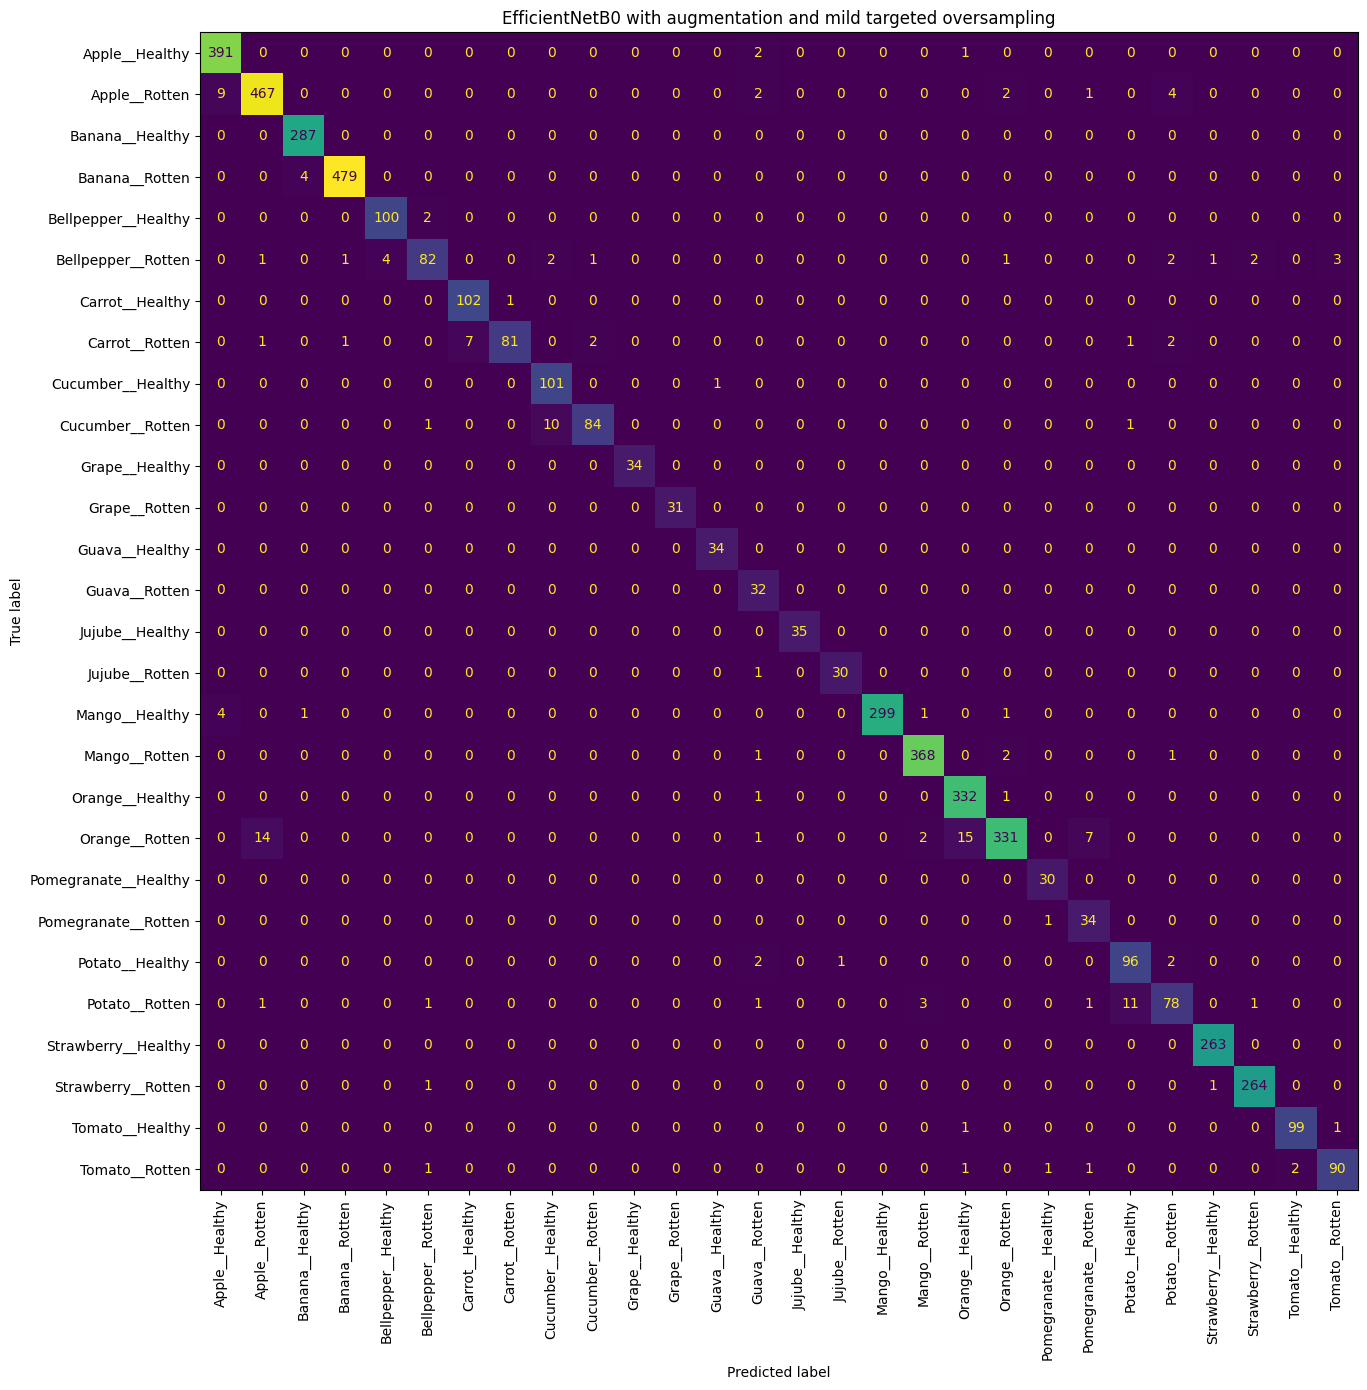

In [12]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("EfficientNetB0 with augmentation and mild targeted oversampling")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 14. Save experiment artifacts

This notebook does not overwrite `models/best_model.keras`. Select the final model only after comparing all candidates.


In [13]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
oversampling_summary.to_csv(oversampling_summary_path, index=False)
history_df.to_csv(FIGURES_DIR / f"{EXPERIMENT_NAME}_history.csv", index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "EfficientNetB0",
    "pretrained_weights": PRETRAINED_WEIGHTS,
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "head_epochs_requested": HEAD_EPOCHS,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "augmentation": True,
    "class_weighting": None,
    "split_strategy": "grouped_source_image_split",
    "split_dir": str(SPLITS_DIR),
    "leakage_prevention": {
        "group_column": "source_image_id",
        "offline_augmented_variants_cross_splits": False,
        "audit_summary": str(SPLITS_DIR / "grouped_split_summary.json"),
    },
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "head_checkpoint": str(head_checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "oversampling_summary": str(oversampling_summary_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved experiment model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved oversampling summary:", oversampling_summary_path)
print("Did not overwrite models/best_model.keras")


Saved experiment model: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/efficientnetb0_aug_oversampled.keras
Saved metadata: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/efficientnetb0_aug_oversampled_metadata.json
Saved oversampling summary: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/efficientnetb0_aug_oversampled_oversampling_summary.csv
Did not overwrite models/best_model.keras


## 15. Decision rule

EfficientNetB0 should be considered better than MobileNetV2 only if it improves macro F1 or materially improves weak rotten-class metrics without a meaningful accuracy drop.

If frozen EfficientNetB0 is close to or better than MobileNetV2, run fine-tuning separately in `05B_efficientnetb0_finetune.ipynb`.
